# ArcFace — Inferencja wytrenowanego modelu

Notebook demonstruje użycie wytrenowanego modelu ArcFace (IResNet50) do:
- ekstrakcji embeddingów twarzy (512-dim),
- weryfikacji 1:1 (porównanie pary zdjęć),
- identyfikacji 1:N (wyszukanie najbardziej podobnej twarzy w galerii).

## Importy

In [1]:
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

## Konfiguracja

In [2]:
# Ścieżki
BASE_DIR = Path(".")
MODEL_WEIGHTS = BASE_DIR / "results" / "arcface_celeba_best.pth"
IMG_DIR = BASE_DIR / "data" / "processed" / "cropped"
IDENTITY_FILE = BASE_DIR / "data" / "identity_CelebA.txt"
TEST_SPLIT_FILE = BASE_DIR / "data" / "split" / "test_split.txt"

# Parametry modelu
EMBEDDING_SIZE = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Definicja architektury — IBasicBlock

In [3]:
class IBasicBlock(nn.Module):
    """Blok residualny IResNet (BN-Conv-BN-PReLU-Conv-BN)."""
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, eps=1e-05)
        self.conv1 = nn.Conv2d(inplanes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, eps=1e-05)
        self.prelu = nn.PReLU(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes, eps=1e-05)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.bn1(x)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return out

## Definicja architektury — IResNet

In [4]:
class IResNet(nn.Module):
    """Improved ResNet for face recognition (insightface architecture).

    Input:  (B, 3, 112, 112)
    Output: (B, embedding_size)  — domyślnie 512
    """
    fc_scale = 7 * 7

    def __init__(self, block, layers, embedding_size=512, dropout=0.0):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64, eps=1e-05)
        self.prelu = nn.PReLU(64)
        self.layer1 = self._make_layer(block, 64, layers[0], stride=2)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.bn2 = nn.BatchNorm2d(512 * block.expansion, eps=1e-05)
        self.dropout = nn.Dropout(p=dropout, inplace=True)
        self.fc = nn.Linear(512 * block.expansion * self.fc_scale, embedding_size)
        self.features = nn.BatchNorm1d(embedding_size, eps=1e-05)
        nn.init.constant_(self.features.weight, 1.0)
        self.features.weight.requires_grad = False

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0, 0.1)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion, eps=1e-05),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.bn2(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.features(x)
        return x

## Funkcja fabryczna `iresnet50`

In [5]:
def iresnet50(**kwargs):
    return IResNet(IBasicBlock, [3, 4, 14, 3], **kwargs)

## Ładowanie wytrenowanego modelu

In [6]:
model = iresnet50(embedding_size=EMBEDDING_SIZE)

state_dict = torch.load(MODEL_WEIGHTS, map_location="cpu", weights_only=True)
state_dict = {k: v.float() if v.dtype == torch.float16 else v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print(f"Model załadowany z: {MODEL_WEIGHTS}")
print(f"Parametry: {sum(p.numel() for p in model.parameters()):,}")

Model załadowany z: results/arcface_celeba_best.pth
Parametry: 43,590,848


## Transformacja obrazów (preprocessing)

In [7]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Funkcja ekstrakcji embeddingu

In [8]:
@torch.no_grad()
def get_embedding(model, image_path, transform=preprocess):
    """Zwraca znormalizowany embedding (512-dim) dla pojedynczego obrazu."""
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)
    emb = model(tensor)
    emb = F.normalize(emb, p=2, dim=1)
    return emb.cpu().squeeze(0)


@torch.no_grad()
def get_embeddings_batch(model, image_paths, transform=preprocess, batch_size=64):
    """Zwraca znormalizowane embeddingi dla listy obrazów."""
    all_emb = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        images = torch.stack([
            transform(Image.open(p).convert("RGB")) for p in batch_paths
        ]).to(device)
        emb = model(images)
        emb = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.cpu())
    return torch.cat(all_emb, dim=0)

## Weryfikacja 1:1 — porównanie dwóch twarzy

In [9]:
def verify(model, img_path1, img_path2, threshold=0.5):
    """Weryfikacja 1:1 — czy dwa zdjęcia przedstawiają tę samą osobę.

    Args:
        model: wytrenowany backbone IResNet50
        img_path1, img_path2: ścieżki do cropowanych zdjęć (112x112)
        threshold: próg cosine similarity (domyślnie 0.5)

    Returns:
        (is_same: bool, similarity: float)
    """
    emb1 = get_embedding(model, img_path1)
    emb2 = get_embedding(model, img_path2)
    similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
    return similarity >= threshold, similarity

## Identyfikacja 1:N — wyszukanie w galerii

In [10]:
def identify(model, query_path, gallery_paths, gallery_labels, top_k=5):
    """Identyfikacja 1:N — wyszukanie najbardziej podobnych twarzy w galerii.

    Args:
        model: wytrenowany backbone IResNet50
        query_path: ścieżka do zdjęcia zapytania
        gallery_paths: lista ścieżek do zdjęć galerii
        gallery_labels: lista etykiet (identity) odpowiadających gallery_paths
        top_k: ile najlepszych wyników zwrócić

    Returns:
        lista krotek (label, similarity, path) posortowana malejąco po similarity
    """
    query_emb = get_embedding(model, query_path).unsqueeze(0)
    gallery_emb = get_embeddings_batch(model, gallery_paths)
    similarities = F.cosine_similarity(query_emb, gallery_emb, dim=1)

    top_indices = similarities.argsort(descending=True)[:top_k]
    results = []
    for idx in top_indices:
        results.append((
            gallery_labels[idx],
            similarities[idx].item(),
            gallery_paths[idx],
        ))
    return results

## Przygotowanie danych testowych

In [11]:
# Wczytanie mapowania: filename -> identity_id
file_to_identity = {}
with open(IDENTITY_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 2:
            continue
        orig_filename, identity_id = parts[0], int(parts[1])
        cropped_name = Path(orig_filename).stem + "_cropped.jpg"
        if (IMG_DIR / cropped_name).exists():
            file_to_identity[cropped_name] = identity_id

# Wczytanie tożsamości ze zbioru testowego
test_ids = set()
with open(TEST_SPLIT_FILE, "r") as f:
    for line in f:
        test_ids.add(int(line.strip()))

# Zbudowanie mapowania identity -> lista plików (tylko test)
identity_to_files = defaultdict(list)
for fname, identity in file_to_identity.items():
    if identity in test_ids:
        identity_to_files[identity].append(fname)

print(f"Tożsamości testowe: {len(identity_to_files)}")
print(f"Obrazów testowych: {sum(len(v) for v in identity_to_files.values())}")

Tożsamości testowe: 1402
Obrazów testowych: 29938


## Demo: Weryfikacja 1:1

Porównanie par zdjęć — positive (ta sama osoba) i negative (różne osoby).

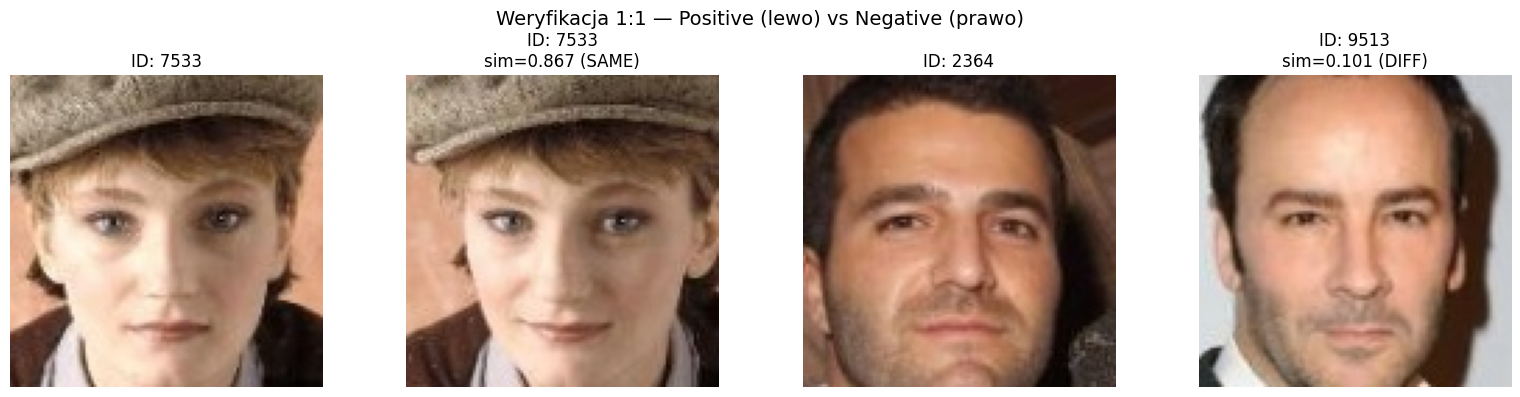

In [12]:
import random
random.seed(42)

# Wybierz tożsamości z >= 2 zdjęciami do pary positive
ids_with_multiple = [id_ for id_, files in identity_to_files.items() if len(files) >= 2]

# Para positive (ta sama osoba)
pos_id = random.choice(ids_with_multiple)
pos_f1, pos_f2 = random.sample(identity_to_files[pos_id], 2)

# Para negative (różne osoby)
neg_id1, neg_id2 = random.sample(list(identity_to_files.keys()), 2)
neg_f1 = random.choice(identity_to_files[neg_id1])
neg_f2 = random.choice(identity_to_files[neg_id2])

# Weryfikacja
pos_same, pos_sim = verify(model, IMG_DIR / pos_f1, IMG_DIR / pos_f2)
neg_same, neg_sim = verify(model, IMG_DIR / neg_f1, IMG_DIR / neg_f2)

# Wizualizacja
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(Image.open(IMG_DIR / pos_f1))
axes[0].set_title(f"ID: {pos_id}")
axes[0].axis("off")

axes[1].imshow(Image.open(IMG_DIR / pos_f2))
axes[1].set_title(f"ID: {pos_id}\nsim={pos_sim:.3f} ({'SAME' if pos_same else 'DIFF'})")
axes[1].axis("off")

axes[2].imshow(Image.open(IMG_DIR / neg_f1))
axes[2].set_title(f"ID: {neg_id1}")
axes[2].axis("off")

axes[3].imshow(Image.open(IMG_DIR / neg_f2))
axes[3].set_title(f"ID: {neg_id2}\nsim={neg_sim:.3f} ({'SAME' if neg_same else 'DIFF'})")
axes[3].axis("off")

fig.suptitle("Weryfikacja 1:1 — Positive (lewo) vs Negative (prawo)", fontsize=14)
plt.tight_layout()
plt.show()

## Demo: Identyfikacja 1:N

Dla wybranego zdjęcia wyszukiwany jest najbardziej podobny obraz w galerii testowej.

Query: 009361_cropped.jpg (tożsamość: 2757)
Galeria: 1402 tożsamości



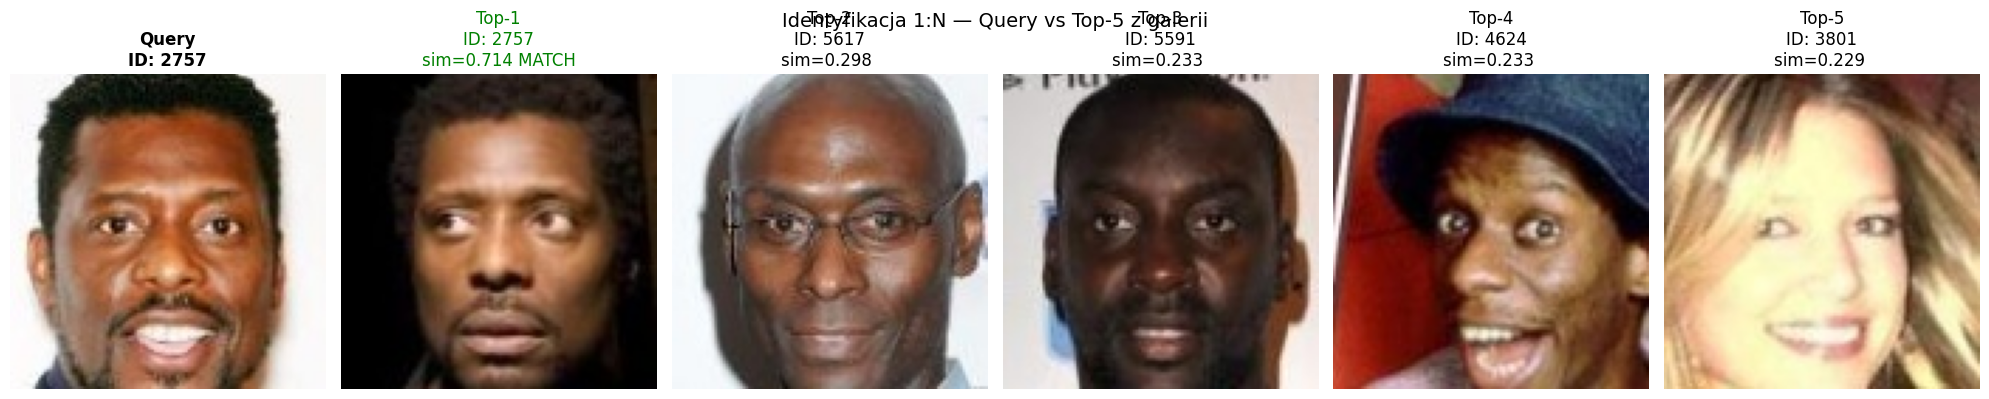


Top-5 wyników:
  1. ID=2757  sim=0.7142  001586_cropped.jpg <-- MATCH
  2. ID=5617  sim=0.2983  005497_cropped.jpg
  3. ID=5591  sim=0.2331  008512_cropped.jpg
  4. ID=4624  sim=0.2330  163462_cropped.jpg
  5. ID=3801  sim=0.2288  008499_cropped.jpg


In [13]:
# Budowanie galerii — jedno zdjęcie na tożsamość
gallery_paths = []
gallery_labels = []
for identity, files in identity_to_files.items():
    gallery_paths.append(IMG_DIR / files[0])
    gallery_labels.append(identity)

# Zdjęcie zapytania — drugie zdjęcie wybranej tożsamości (nie w galerii)
query_id = random.choice(ids_with_multiple)
query_file = identity_to_files[query_id][1]  # inne zdjęcie niż w galerii
query_path = IMG_DIR / query_file

print(f"Query: {query_file} (tożsamość: {query_id})")
print(f"Galeria: {len(gallery_paths)} tożsamości")
print()

# Identyfikacja
results = identify(model, query_path, gallery_paths, gallery_labels, top_k=5)

# Wizualizacja
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(Image.open(query_path))
axes[0].set_title(f"Query\nID: {query_id}", fontweight="bold")
axes[0].axis("off")

for i, (label, sim, path) in enumerate(results):
    match = "MATCH" if label == query_id else ""
    color = "green" if label == query_id else "black"
    axes[i + 1].imshow(Image.open(path))
    axes[i + 1].set_title(f"Top-{i+1}\nID: {label}\nsim={sim:.3f} {match}", color=color)
    axes[i + 1].axis("off")

fig.suptitle("Identyfikacja 1:N — Query vs Top-5 z galerii", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop-5 wyników:")
for i, (label, sim, path) in enumerate(results):
    match = " <-- MATCH" if label == query_id else ""
    print(f"  {i+1}. ID={label}  sim={sim:.4f}  {Path(path).name}{match}")

## Demo: Ekstrakcja embeddingu dla dowolnego obrazu

In [14]:
# Przykład ekstrakcji surowego embeddingu
sample_file = list(identity_to_files.values())[0][0]
sample_path = IMG_DIR / sample_file

embedding = get_embedding(model, sample_path)

print(f"Obraz: {sample_file}")
print(f"Embedding shape: {embedding.shape}")
print(f"Embedding norm (L2): {embedding.norm().item():.4f}")
print(f"Embedding (pierwsze 10 wartości): {embedding[:10].numpy()}")

Obraz: 000001_cropped.jpg
Embedding shape: torch.Size([512])
Embedding norm (L2): 1.0000
Embedding (pierwsze 10 wartości): [ 0.05484137  0.04211314  0.0001178  -0.06706978  0.02663172 -0.00816762
  0.00882432  0.07394587  0.00343252  0.0573167 ]
